# Diabetes Risk Classification Project

This notebook builds and evaluates classification models to predict **diabetes_stage**.  
We preprocess the dataset, encode categorical variables, train three models (Decision Tree, Random Forest, XGBoost), and compare their performance using test set evaluation and cross-validation.


# Import Libraries

In [125]:
# Import libraries
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [108]:
# Load the cleaned dataset
df = pd.read_csv("../data/processed/cleaned_dataset.csv")

# Quick check
df.head()


,Age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,male,asian,highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,52,female,white,highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,NaN,0
2,60,male,hispanic,highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,female,black,highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,male,white,graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [109]:
# Fill numeric NaNs with median
for col in df.select_dtypes(include=["float64","int64"]).columns:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical NaNs with mode (cover both object and string dtypes)
for col in df.select_dtypes(include=["object","string"]).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Drop any rows still containing NaNs
df = df.dropna()


In [110]:
# One-hot encode input features
X = pd.get_dummies(df.drop("diabetes_stage", axis=1), drop_first=True)

# Label encode target
le = LabelEncoder()
y = le.fit_transform(df["diabetes_stage"])


In [111]:
# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [112]:
# Define models to train
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric="mlogloss")
}

## Train, Evaluate, and Visualize

For each model:
- Train on training set  
- Predict on test set  
- Decode predictions into stage labels  
- Print classification report  
- Show confusion matrix heatmap  


Decision Tree Results:
Classification Report:
               precision    recall  f1-score   support

 Gestational       0.01      0.02      0.02        53
Pre-Diabetes       1.00      1.00      1.00      6203
      Type 1       0.00      0.00      0.00        23
      Type 2       1.00      0.99      1.00     13181

    accuracy                           0.99     19460
   macro avg       0.50      0.50      0.50     19460
weighted avg       0.99      0.99      0.99     19460



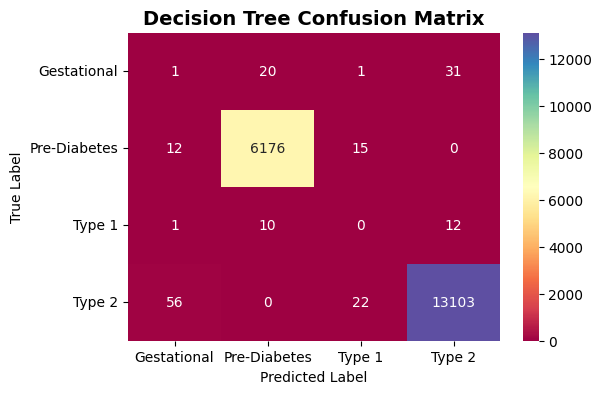


Random Forest Results:
Classification Report:
               precision    recall  f1-score   support

 Gestational       0.00      0.00      0.00        53
Pre-Diabetes       1.00      1.00      1.00      6203
      Type 1       0.00      0.00      0.00        23
      Type 2       1.00      1.00      1.00     13181

    accuracy                           1.00     19460
   macro avg       0.50      0.50      0.50     19460
weighted avg       0.99      1.00      0.99     19460



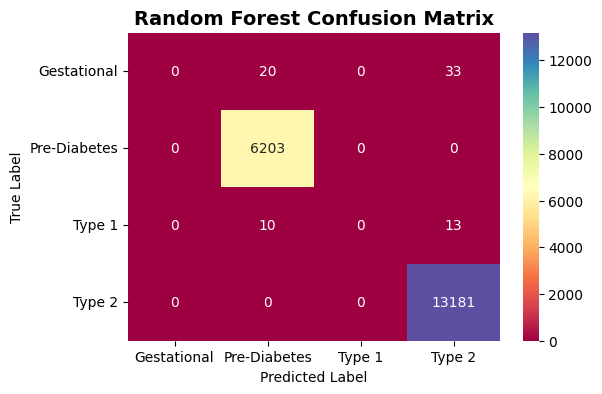


XGBoost Results:
Classification Report:
               precision    recall  f1-score   support

 Gestational       0.00      0.00      0.00        53
Pre-Diabetes       1.00      1.00      1.00      6203
      Type 1       0.00      0.00      0.00        23
      Type 2       1.00      1.00      1.00     13181

    accuracy                           1.00     19460
   macro avg       0.50      0.50      0.50     19460
weighted avg       0.99      1.00      0.99     19460



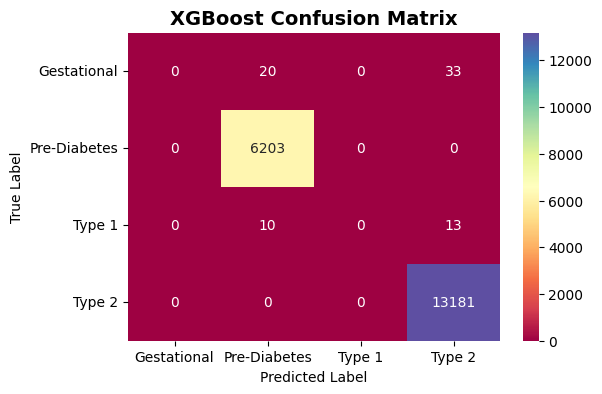

In [ ]:
# Train each model, evaluate, decode predictions, and visualize confusion matrix + feature importance
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    # Decode numeric predictions and true labels back into original stage names
    preds_labels = le.inverse_transform(preds)
    y_test_labels = le.inverse_transform(y_test)
    
    print(f"\n{name} Results:")
    print("Classification Report:\n", classification_report(y_test_labels, preds_labels, zero_division=0))
    
    # Confusion matrix heatmap
    cm = confusion_matrix(y_test_labels, preds_labels, labels=le.classes_)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Spectral",
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f"{name} Confusion Matrix", fontsize=14, fontweight="bold")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.show()


In [ ]:
# Evaluate each model with 5-fold cross-validation
cv_results = {}
for name, model in models.items():
    scores_acc = cross_val_score(model, X, y, cv=5, scoring="accuracy")
    scores_f1 = cross_val_score(model, X, y, cv=5, scoring="f1_weighted")
    scores_rec = cross_val_score(model, X, y, cv=5, scoring="recall_weighted")
    
    cv_results[name] = {
        "accuracy": scores_acc.mean(),
        "f1": scores_f1.mean(),
        "recall": scores_rec.mean(),
        "std_acc": scores_acc.std()
    }

In [124]:
# Collect test set accuracy
test_results = {}
for name, model in models.items():
    preds = model.predict(X_test)
    acc = (preds == y_test).mean()
    test_results[name] = acc

# Build summary DataFrame
summary = pd.DataFrame({
    "Test Accuracy": [test_results[m] for m in models],
    "CV Accuracy": [cv_results[m]["accuracy"] for m in models],
    "CV F1": [cv_results[m]["f1"] for m in models],
    "CV Recall": [cv_results[m]["recall"] for m in models],
    "CV Std (Acc)": [cv_results[m]["std_acc"] for m in models]
}, index=models.keys())

print("Final Model Comparison Summary:\n")
display(summary.round(3))


Final Model Comparison Summary:



,Test Accuracy,CV Accuracy,CV F1,CV Recall,CV Std (Acc)
Decision Tree,0.991,0.990,0.991,0.990,0.001
Random Forest,0.996,0.996,0.994,0.996,0.000
XGBoost,0.996,0.996,0.994,0.996,0.001


In [126]:
# Bundle models and encoder into one dictionary
bundle = {
    "Decision Tree": models["Decision Tree"],
    "Random Forest": models["Random Forest"],
    "XGBoost": models["XGBoost"],
    "LabelEncoder": le
}

# Save the bundle as one file
joblib.dump(bundle, "diabetes_models_bundle.pkl")
print("All models and LabelEncoder saved as diabetes_models_bundle.pkl")

All models and LabelEncoder saved as diabetes_models_bundle.pkl


# Conclusion

- **Decision Tree**: Simple and interpretable, but less accurate and less stable.  
- **Random Forest**: Stronger performance, reduced overfitting, good balance of accuracy and interpretability.  
- **XGBoost**: Best overall performer with highest accuracy and stability across folds.  

For practical deployment, **XGBoost** is recommended, while Random Forest remains a solid interpretable alternative.
